<a href="https://colab.research.google.com/github/Skullo-bot/ames-housing-advanced-regression/blob/main/house_prices_advanced_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import logging
import warnings
from dataclasses import dataclass, field
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

In [94]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("house_prices")


# CONFIG

In [95]:
@dataclass
class Config:
    """Central place for paths and hyperparameters — edit here, not in the body."""
    train_path: str = "train.csv"
    test_path: str = "test.csv"
    sample_sub_path: str = "sample_submission.csv"
    random_state: int = 42
    n_cv_folds: int = 5
    outlier_grlivarea_threshold: int = 4000
    outlier_saleprice_threshold: int = 300000
    output_submission_path: str = "submission.csv"

    none_fill_cols: Tuple[str, ...] = (
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
        "MasVnrType",
    )

    zero_fill_cols: Tuple[str, ...] = (
        "GarageYrBlt", "GarageArea", "GarageCars",
        "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
        "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
    )
    quality_map: Dict[str, int] = field(default_factory=lambda: {
        "None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5
    })
    quality_cols: Tuple[str, ...] = (
        "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
        "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond",
    )

# 1. Data Loading

In [96]:
def load_data(cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load train/test/sample submission with explicit error handling."""
    try:
        train = pd.read_csv(cfg.train_path)
        test = pd.read_csv(cfg.test_path)
        sample_sub = pd.read_csv(cfg.sample_sub_path)
    except FileNotFoundError as e:
        log.error(f"Could not find one of the input files: {e}")
        log.error("Upload train.csv / test.csv / sample_submission.csv to the "
                   "Colab session, or update Config paths.")
        raise
    log.info(f"Loaded train {train.shape}, test {test.shape}")
    return train, test, sample_sub

# 2. DATA QUALITY ASSESSMENT

In [97]:
def assess_data_quality(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    """
    Report missing values, duplicates, and flag columns where missingness is
    structural (per the data dictionary) rather than a genuine data problem.
    Returns a summary DataFrame for the report.
    """
    miss = train.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(train) * 100).round(1)
    summary = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})

    dup_count = train.duplicated().sum()

    log.info("=" * 70)
    log.info("DATA QUALITY ASSESSMENT")
    log.info("=" * 70)
    log.info(f"Duplicate rows: {dup_count}")
    log.info(f"Columns with missing values: {len(summary)} / {train.shape[1]}")
    log.info(f"\n{summary.to_string()}")

    if dup_count > 0:
        log.warning(f"{dup_count} duplicate rows found — review before modeling.")


    visualize_missing_data(summary)


    return summary


In [98]:
def visualize_missing_data(summary: pd.DataFrame) -> None:
    """
    Plot a bar chart of the columns with missing data and their missing percentages
    to help stakeholders assess data completeness.
    """
    try:
        if len(summary) == 0:
            log.info("No missing data to visualize.")
            return

        plt.figure(figsize=(12, 6))
        sns.barplot(x=summary["missing_pct"], y=summary.index, palette="Reds_r", hue=summary.index, legend=False)

        # Add values on bars
        for i, val in enumerate(summary["missing_pct"]):
            plt.text(
                val + 0.5, i,
                f"{val:.1f}% ({int(summary['missing_count'].iloc[i])})",
                va='center',
                fontsize=9
            )

        plt.title("Data Completeness: Percentage of Missing Values by Feature", pad=15)
        plt.xlabel("Percentage Missing (%)")
        plt.ylabel("Feature")
        plt.xlim(0, 110)
        plt.tight_layout()
        plt.savefig("data_quality_missing_values.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not visualize missing data: {e}")






In [99]:
def visualize_outlier_removal(train_before: pd.DataFrame, train_after: pd.DataFrame, outliers: pd.DataFrame) -> None:
    """
    Generate a side-by-side scatter plot of GrLivArea vs SalePrice before and after
    outlier removal to visually confirm the data cleaning process.
    """
    try:
        if len(outliers) == 0:
            log.info("No outliers to plot.")
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))


        sns.scatterplot(
            data=train_before,
            x="GrLivArea",
            y="SalePrice",
            hue="OverallQual",
            palette="viridis",
            alpha=0.6,
            s=40,
            ax=axes[0]
        )

        for _, row in outliers.iterrows():
            axes[0].scatter(
                row["GrLivArea"],
                row["SalePrice"],
                facecolors='none',
                edgecolors='red',
                s=150,
                linewidths=2
            )
            axes[0].annotate(
                f"Outlier Id {int(row['Id'])}",
                xy=(row["GrLivArea"], row["SalePrice"]),
                xytext=(row["GrLivArea"] - 1000, row["SalePrice"] + 50000),
                arrowprops=dict(facecolor='red', arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
                color="red",
                weight="bold"
            )
        axes[0].axvline(4000, color="red", linestyle="--", alpha=0.5)
        axes[0].set_title("Before Outlier Removal\n(Highlighted anomalies to be removed)")
        axes[0].set_ylabel("Sale Price ($)")
        axes[0].set_xlabel("Above Grade Living Area (sqft)")
        axes[0].get_legend().remove()


        sns.scatterplot(
            data=train_after,
            x="GrLivArea",
            y="SalePrice",
            hue="OverallQual",
            palette="viridis",
            alpha=0.6,
            s=40,
            ax=axes[1]
        )
        axes[1].axvline(4000, color="red", linestyle="--", alpha=0.5)
        axes[1].set_title("After Outlier Removal\n(Cleaned dataset for training)")
        axes[1].set_ylabel("Sale Price ($)")
        axes[1].set_xlabel("Above Grade Living Area (sqft)")
        axes[1].legend(title="OverallQual", bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.suptitle("Outlier Preprocessing: Before vs. After Cleaning", y=1.02)
        plt.tight_layout()
        plt.savefig("data_quality_outlier_removal.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not visualize outlier removal: {e}")




In [100]:
def visualize_feature_scaling(X_before: pd.DataFrame, X_after_arr: np.ndarray, feature_names: pd.Index) -> None:
    """
    Generate a side-by-side distribution plot comparing key features before and after
    StandardScaler normalization to show how scaling levels the playing field for linear models.
    """
    try:
        feat1 = "TotalSF" if "TotalSF" in X_before.columns else X_before.columns[0]
        feat2 = "OverallQual" if "OverallQual" in X_before.columns else X_before.columns[1]

        idx1 = X_before.columns.get_loc(feat1)
        idx2 = X_before.columns.get_loc(feat2)

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Raw features (Before scaling)
        sns.histplot(X_before[feat1], kde=True, ax=axes[0, 0], color="#2b5c8f")
        axes[0, 0].set_title(f"{feat1} (Before Scaling)")
        axes[0, 0].set_xlabel("Value")

        sns.histplot(X_before[feat2], kde=True, ax=axes[1, 0], color="#c44e52")
        axes[1, 0].set_title(f"{feat2} (Before Scaling)")
        axes[1, 0].set_xlabel("Value")

        # Scaled features (After scaling)
        sns.histplot(X_after_arr[:, idx1], kde=True, ax=axes[0, 1], color="#1e7d55")
        axes[0, 1].set_title(f"{feat1} (After Scaling — Mean≈0, Std≈1)")
        axes[0, 1].set_xlabel("Standardized Value")

        sns.histplot(X_after_arr[:, idx2], kde=True, ax=axes[1, 1], color="#8172b3")
        axes[1, 1].set_title(f"{feat2} (After Scaling — Mean≈0, Std≈1)")
        axes[1, 1].set_xlabel("Standardized Value")

        plt.suptitle("Feature Scaling Diagnostics: Before vs. After Normalization", y=1.02)
        plt.tight_layout()
        plt.savefig("data_preprocessing_feature_scaling.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not visualize feature scaling: {e}")


In [101]:
def detect_outliers(train: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Flag the documented GrLivArea outliers (large homes sold unusually cheap —
    disclosed by the dataset author as anomalies, likely non-market sales).
    Using IQR alone here would over-flag legitimately large/expensive homes,
    so we apply the documented, domain-informed rule instead.
    """
    mask = (
        (train["GrLivArea"] > cfg.outlier_grlivarea_threshold)
        & (train["SalePrice"] < cfg.outlier_saleprice_threshold)
    )
    outliers = train[mask]
    log.info(f"Detected {len(outliers)} documented outlier(s) by GrLivArea/SalePrice rule: "
              f"{outliers['Id'].tolist()}")
    return outliers

# 3. EXPLORATORY DATA ANALYSIS

In [102]:
def run_eda(train: pd.DataFrame) -> None:
    """
    Descriptive stats, distribution, correlation, and segment analysis.
    Saves PNG charts to disk (Colab will render them inline automatically
    when this script is run cell-by-cell).
    """
    log.info("=" * 70)
    log.info("EXPLORATORY DATA ANALYSIS")
    log.info("=" * 70)


    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.titlesize"] = 16
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10

    desc = train["SalePrice"].describe()
    skew = train["SalePrice"].skew()
    kurt = train["SalePrice"].kurtosis()
    log.info(f"SalePrice descriptive stats:\n{desc}")
    log.info(f"Skewness: {skew:.3f} | Kurtosis: {kurt:.3f} "
              f"({'right-skewed — log transform recommended' if skew > 0.5 else 'approx symmetric'})")


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw SalePrice
    sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="#2b5c8f")
    axes[0].axvline(desc["mean"], color="red", linestyle="--", label=f"Mean: ${desc['mean']:,.0f}")
    axes[0].axvline(desc["50%"], color="green", linestyle="-.", label=f"Median: ${desc['50%']:,.0f}")
    axes[0].set_title(f"SalePrice (Raw Distribution)\nSkewness: {skew:.2f} | Kurtosis: {kurt:.2f}")
    axes[0].set_xlabel("Sale Price ($)")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    # Log-transformed SalePrice
    log_sp = np.log1p(train["SalePrice"])
    sns.histplot(log_sp, kde=True, ax=axes[1], color="#1e7d55")
    axes[1].axvline(log_sp.mean(), color="red", linestyle="--", label=f"Mean: {log_sp.mean():.2f}")
    axes[1].axvline(log_sp.median(), color="green", linestyle="-.", label=f"Median: {log_sp.median():.2f}")
    axes[1].set_title(f"log1p(SalePrice) (Normal-like Distribution)\nSkewness: {log_sp.skew():.2f} | Kurtosis: {log_sp.kurtosis():.2f}")
    axes[1].set_xlabel("log1p(Sale Price)")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    plt.suptitle("Target Variable Analysis: Transforming SalePrice to Resolve Right-Skewness", y=1.02)
    plt.tight_layout()
    plt.savefig("eda_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    #     for multicollinearity before modeling) ---
    num_cols = train.select_dtypes(include=[np.number]).columns
    corr_target = train[num_cols].corr()["SalePrice"].sort_values(ascending=False)
    log.info(f"Top 10 numeric correlations with SalePrice:\n{corr_target.head(11)}")

    top_feats = corr_target.abs().sort_values(ascending=False).head(12).index


    plt.figure(figsize=(10, 8))
    sns.heatmap(
        train[top_feats].corr(),
        annot=True,
        fmt=".2f",
        cmap="RdYlBu_r",
        center=0,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title("Correlation Matrix: Top 12 Features Strongly Associated with SalePrice", pad=20)
    plt.tight_layout()
    plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    #     for unobserved quality-of-life factors in real estate) ---
    nb_stats = (
        train.groupby("Neighborhood")["SalePrice"]
        .agg(["median", "mean", "count"])
        .sort_values("median", ascending=False)
    )
    log.info(f"Neighborhood price segmentation (top 5 / bottom 5):\n"
              f"{nb_stats.head(5)}\n...\n{nb_stats.tail(5)}")


    plt.figure(figsize=(14, 7))
    order = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, palette="viridis")
    plt.xticks(rotation=45, ha='right')
    plt.title("SalePrice Distribution by Neighborhood (Ordered by Median Price)", pad=15)
    plt.ylabel("Sale Price ($)")
    plt.xlabel("Neighborhood")

    global_median = train["SalePrice"].median()
    plt.axhline(global_median, color="red", linestyle="--", alpha=0.7, label=f"Global Median Price (${global_median:,.0f})")
    plt.legend()

    plt.tight_layout()
    plt.savefig("eda_neighborhood_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(9, 6))
    sns.boxplot(data=train, x="OverallQual", y="SalePrice", palette="Blues")
    plt.title("SalePrice vs Overall Quality Rating (Strong Ordinal Association)", pad=15)
    plt.ylabel("Sale Price ($)")
    plt.xlabel("Overall Quality Rating (1 = Very Poor, 10 = Very Excellent)")
    plt.tight_layout()
    plt.savefig("eda_overallqual_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=train,
        x="GrLivArea",
        y="SalePrice",
        hue="OverallQual",
        palette="viridis",
        alpha=0.7,
        s=50
    )

    # Highlight the documented outliers
    outliers = train[
        (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
    ]
    for _, row in outliers.iterrows():
        plt.scatter(
            row["GrLivArea"],
            row["SalePrice"],
            facecolors='none',
            edgecolors='red',
            s=200,
            linewidths=2,
            label="Identified Outlier" if "Identified Outlier" not in plt.gca().get_legend_handles_labels()[1] else ""
        )
        # Add text label next to the outliers
        plt.annotate(
            f"Outlier (Id {int(row['Id'])})",
            xy=(row["GrLivArea"], row["SalePrice"]),
            xytext=(row["GrLivArea"] - 800, row["SalePrice"] + 30000),
            arrowprops=dict(facecolor='red', arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
            color="red",
            weight="bold"
        )

    plt.axvline(4000, color="red", linestyle="--", alpha=0.5, label="Outlier Threshold (4,000 sqft)")
    plt.legend(title="OverallQual", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title("GrLivArea vs SalePrice: Highlighting Anomalous Outliers", pad=15)
    plt.ylabel("Sale Price ($)")
    plt.xlabel("Above Grade Living Area (sqft)")
    plt.tight_layout()
    plt.savefig("eda_grlivarea_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# 4. STATISTICAL ANALYSIS

In [103]:
def run_statistical_tests(train: pd.DataFrame) -> None:
    """
    Formal hypothesis tests to back up EDA observations with significance
    and effect size — not just visual impressions.
    """
    log.info("=" * 70)
    log.info("STATISTICAL ANALYSIS")
    log.info("=" * 70)

    # --- Test 1: Pearson correlation significance (GrLivArea vs SalePrice) ---
    # Why Pearson: both variables continuous, relationship visually linear.
    # H0: no linear correlation (r = 0)
    r, p_value = stats.pearsonr(train["GrLivArea"], train["SalePrice"])
    log.info(f"[Pearson] GrLivArea vs SalePrice: r={r:.3f}, p={p_value:.2e} "
              f"({'reject H0 — significant linear relationship' if p_value < 0.05 else 'fail to reject H0'})")

    # --- Test 2: One-way ANOVA — does Neighborhood explain SalePrice variance? ---
    # Why ANOVA: comparing means of a continuous variable (SalePrice) across
    # >2 independent categorical groups (Neighborhood).
    # H0: all neighborhood means are equal.
    groups = [g["SalePrice"].values for _, g in train.groupby("Neighborhood")]
    f_stat, p_anova = stats.f_oneway(*groups)
    # Effect size: eta-squared = SS_between / SS_total
    grand_mean = train["SalePrice"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((train["SalePrice"] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total
    log.info(f"[ANOVA] SalePrice ~ Neighborhood: F={f_stat:.2f}, p={p_anova:.2e}, "
              f"eta^2={eta_sq:.3f} "
              f"({'large' if eta_sq > 0.14 else 'medium' if eta_sq > 0.06 else 'small'} effect) "
              f"({'reject H0 — neighborhood matters' if p_anova < 0.05 else 'fail to reject H0'})")

    # --- Test 3: Welch's t-test — CentralAir Y vs N ---
    # Why Welch's (not Student's): group sizes and variances are unequal here.
    ca_yes = train.loc[train["CentralAir"] == "Y", "SalePrice"]
    ca_no = train.loc[train["CentralAir"] == "N", "SalePrice"]
    t_stat, p_ttest = stats.ttest_ind(ca_yes, ca_no, equal_var=False)
    # Effect size: Cohen's d
    pooled_std = np.sqrt((ca_yes.var() + ca_no.var()) / 2)
    cohens_d = (ca_yes.mean() - ca_no.mean()) / pooled_std
    log.info(f"[Welch t-test] SalePrice ~ CentralAir: t={t_stat:.2f}, p={p_ttest:.2e}, "
              f"Cohen's d={cohens_d:.2f} "
              f"(mean diff = ${ca_yes.mean() - ca_no.mean():,.0f})")

    log.info(
        "NOTE: These tests establish statistical association, not causation. "
        "OverallQual, Neighborhood, and size features are likely correlated with "
        "each other (confounding) — a regression model that includes them jointly "
        "is needed to isolate each factor's marginal contribution."
    )


# 5. DATA CLEANING

In [104]:
def clean_data(train: pd.DataFrame, test: pd.DataFrame, cfg: Config) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """
    Remove documented outliers, combine train+test for consistent imputation,
    and fill missing values based on their documented meaning (not blind
    mean/mode imputation).
    Returns (all_data, y_log, test_ids).
    """
    outliers = detect_outliers(train, cfg)
    train_clean = train[~train["Id"].isin(outliers["Id"])].reset_index(drop=True)
    log.info(f"Train shape after removing {len(outliers)} outlier(s): {train_clean.shape}")

    test_ids = test["Id"].copy()
    y_log = np.log1p(train_clean["SalePrice"])  # aligns with competition's log-RMSE metric

    all_data = pd.concat(
        [train_clean.drop(columns=["SalePrice"]), test], axis=0, ignore_index=True
    )

    # Structural NAs -> "None" category
    for col in cfg.none_fill_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].fillna("None")

    # Structural NAs -> 0 (feature absent)
    for col in cfg.zero_fill_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].fillna(0)

    # LotFrontage: neighborhood-level median is more accurate than a global
    # median, since lot sizes vary systematically by area.
    all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )

    # Functional: data description explicitly states NA -> "Typ" (typical)
    all_data["Functional"] = all_data.get("Functional", pd.Series(dtype=object)).fillna("Typ")

    # Any remaining categorical NAs (rare, e.g. Electrical/MSZoning/SaleType):
    # mode imputation is reasonable since <1% missing.
    cat_cols = all_data.select_dtypes(include="object").columns
    for col in cat_cols:
        n_missing = all_data[col].isnull().sum()
        if n_missing > 0:
            mode_val = all_data[col].mode()[0]
            all_data[col] = all_data[col].fillna(mode_val)
            log.info(f"Imputed {n_missing} missing values in '{col}' with mode '{mode_val}'")

    remaining_na = all_data.isnull().sum().sum()
    if remaining_na > 0:
        log.warning(f"{remaining_na} missing values remain after cleaning — inspect before modeling.")
    else:
        log.info("No missing values remain after cleaning.")

    return all_data, y_log, test_ids


# 6. FEATURE ENGINEERING

In [105]:
def engineer_features(all_data: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Create derived features that better capture business-meaningful drivers
    of price than the raw columns alone (e.g. total living area, house age).
    """
    all_data = all_data.copy()

    all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
    all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
    all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
    all_data["TotalBath"] = (
        all_data["FullBath"] + 0.5 * all_data["HalfBath"]
        + all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"]
    )
    all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
    all_data["Has2ndFlr"] = (all_data["2ndFlrSF"] > 0).astype(int)
    all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
    all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
    all_data["IsNew"] = (all_data["YrSold"] == all_data["YearBuilt"]).astype(int)

    # These are numeric-coded but semantically categorical (no ordinal meaning)
    all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
    all_data["MoSold"] = all_data["MoSold"].astype(str)

    # Ordinal quality columns -> numeric rank (preserves Ex > Gd > TA > ... order,
    # which one-hot encoding would discard)
    for col in cfg.quality_cols:
        all_data[col] = all_data[col].map(cfg.quality_map).fillna(0)

    log.info(f"Feature engineering complete. Shape before encoding: {all_data.shape}")
    return all_data




In [106]:
def encode_features(all_data: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode remaining nominal categorical columns."""
    encoded = pd.get_dummies(all_data, drop_first=True)
    log.info(f"Shape after one-hot encoding: {encoded.shape}")
    return encoded

# 7. MODELING

In [107]:
def build_candidate_models(cfg: Config) -> Dict[str, object]:
    """Baseline candidate models spanning linear (regularized) and tree-based families."""
    models = {
        "Ridge": Ridge(alpha=10, random_state=cfg.random_state),
        "Lasso": Lasso(alpha=0.001, random_state=cfg.random_state, max_iter=20000),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=cfg.random_state, max_iter=20000),
        "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=15, random_state=cfg.random_state, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3, random_state=cfg.random_state
        ),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=800, learning_rate=0.03, max_depth=3,
            subsample=0.8, colsample_bytree=0.8, random_state=cfg.random_state,
            objective="reg:squarederror",
        )
    else:
        log.warning("xgboost not installed — skipping. Run `!pip install xgboost` in Colab to include it.")
    return models

In [108]:
def evaluate_models(models: Dict[str, object], X: pd.DataFrame, X_scaled: np.ndarray,
                     y: pd.Series, cfg: Config) -> pd.DataFrame:
    """
    Cross-validated RMSE (log scale, matching the competition metric) for
    each candidate model. Linear models use scaled features; tree-based
    models use raw features (scaling doesn't affect tree splits).
    """
    kf = KFold(n_splits=cfg.n_cv_folds, shuffle=True, random_state=cfg.random_state)
    linear_models = {"Ridge", "Lasso", "ElasticNet"}
    rows = []

    for name, model in models.items():
        try:
            X_input = X_scaled if name in linear_models else X.values
            scores = cross_val_score(model, X_input, y, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1)
            rmse = np.sqrt(-scores)
            rows.append({"model": name, "rmse_mean": rmse.mean(), "rmse_std": rmse.std()})
            log.info(f"{name:<18} CV RMSE(log) = {rmse.mean():.4f} (+/- {rmse.std():.4f})")
        except Exception as e:
            log.error(f"{name} failed during cross-validation: {e}")

    results = pd.DataFrame(rows).sort_values("rmse_mean").reset_index(drop=True)
    return results

In [109]:
def tune_best_model(best_name: str, models: Dict[str, object], X: pd.DataFrame,
                     X_scaled: np.ndarray, y: pd.Series, cfg: Config):
    """
    Light hyperparameter search around the best baseline model's neighborhood.
    Kept intentionally small (grid, not random/bayesian) for runtime predictability
    in a Colab session; widen param_grids if more search budget is available.
    """
    linear_models = {"Ridge", "Lasso", "ElasticNet"}
    X_input = X_scaled if best_name in linear_models else X.values

    param_grids = {
        "Ridge": {"alpha": [1, 5, 10, 20, 30]},
        "Lasso": {"alpha": [0.0005, 0.001, 0.005, 0.01]},
        "ElasticNet": {"alpha": [0.0005, 0.001, 0.005], "l1_ratio": [0.2, 0.5, 0.8]},
        "RandomForest": {"n_estimators": [300, 500], "max_depth": [10, 15, 20]},
        "GradientBoosting": {"n_estimators": [400, 600], "learning_rate": [0.03, 0.05], "max_depth": [2, 3]},
        "XGBoost": {"n_estimators": [600, 900], "learning_rate": [0.02, 0.03], "max_depth": [3, 4]},
    }

    if best_name not in param_grids:
        log.warning(f"No tuning grid defined for {best_name}; using baseline params.")
        return models[best_name]

    kf = KFold(n_splits=cfg.n_cv_folds, shuffle=True, random_state=cfg.random_state)
    try:
        search = GridSearchCV(
            models[best_name], param_grids[best_name],
            scoring="neg_mean_squared_error", cv=kf, n_jobs=-1
        )
        search.fit(X_input, y)
        best_rmse = np.sqrt(-search.best_score_)
        log.info(f"Tuned {best_name}: best params={search.best_params_}, CV RMSE(log)={best_rmse:.4f}")
        return search.best_estimator_
    except Exception as e:
        log.error(f"Hyperparameter tuning failed for {best_name}: {e}. Falling back to baseline.")
        return models[best_name]

In [110]:
def build_stacking_ensemble(cfg: Config) -> StackingRegressor:
    """
    Combine diverse base learners (linear + tree-based) with a Ridge
    meta-learner. Ensembling typically reduces variance vs any single model
    and is standard practice for this competition's leaderboard.
    """
    estimators = [
        ("ridge", Ridge(alpha=10, random_state=cfg.random_state)),
        ("gbm", GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3, random_state=cfg.random_state
        )),
        ("rf", RandomForestRegressor(n_estimators=300, max_depth=15, random_state=cfg.random_state, n_jobs=-1)),
    ]
    if HAS_XGB:
        estimators.append(("xgb", XGBRegressor(
            n_estimators=800, learning_rate=0.03, max_depth=3,
            subsample=0.8, colsample_bytree=0.8, random_state=cfg.random_state,
            objective="reg:squarederror",
        )))
    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=5, random_state=cfg.random_state),
        cv=cfg.n_cv_folds,
        n_jobs=-1,
    )
    return stack

# 8. FEATURE IMPORTANCE

In [111]:
def report_feature_importance(model, feature_names: pd.Index, top_n: int = 15) -> None:
    """Print top drivers, using whichever attribute the fitted model exposes."""
    try:
        if hasattr(model, "feature_importances_"):
            importances = pd.Series(model.feature_importances_, index=feature_names)
            log.info(f"Top {top_n} features by importance:\n"
                      f"{importances.sort_values(ascending=False).head(top_n)}")
        elif hasattr(model, "coef_"):
            coefs = pd.Series(model.coef_, index=feature_names)
            log.info(f"Top {top_n} features by |coefficient|:\n"
                      f"{coefs.abs().sort_values(ascending=False).head(top_n)}")
        else:
            log.info("Selected model does not expose native feature importance "
                      "(e.g. stacking ensemble) — inspect base learners individually if needed.")
    except Exception as e:
        log.warning(f"Could not extract feature importance: {e}")




In [112]:
def visualize_model_comparison(results: pd.DataFrame) -> None:
    """
    Plot a comparison of CV RMSE across all candidate models and ensembling methods.
    Includes error bars representing the standard deviation of cross-validation scores.
    """
    try:
        plt.figure(figsize=(10, 6))
        # Sort so best models are at the top
        sorted_res = results.sort_values("rmse_mean", ascending=True)

        # Create bar chart with error bars
        bars = plt.barh(
            sorted_res["model"],
            sorted_res["rmse_mean"],
            xerr=sorted_res["rmse_std"],
            color="#2b5c8f",
            edgecolor="none",
            height=0.6,
            capsize=5,
            error_kw=dict(ecolor="orange", lw=1.5, capthick=1.5)
        )

        # Highlight the best model in green
        bars[0].set_color("#1e7d55")

        # Add labels to the bars
        for bar in bars:
            width = bar.get_width()
            plt.text(
                width + 0.002,
                bar.get_y() + bar.get_height()/2,
                f"{width:.4f}",
                va='center',
                ha='left',
                fontsize=10,
                fontweight='semibold'
            )

        plt.title("Model Comparison: 5-Fold Cross-Validation RMSE (Log Scale)", pad=15)
        plt.xlabel("Mean CV RMSE (Log Scale) — Lower is Better")
        plt.ylabel("Candidate Model")

        # Set x limits to zoom in on the relevant range
        min_val = sorted_res["rmse_mean"].min()
        max_val = sorted_res["rmse_mean"].max()
        plt.xlim(max(0, min_val - 0.02), max_val + 0.02)

        plt.tight_layout()
        plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate model comparison plot: {e}")




In [113]:
def visualize_predictions_vs_actuals(y_true: pd.Series, y_pred: np.ndarray, res_std: float) -> None:
    """
    Plot actual vs predicted house prices on both normal (USD) and log scale
    to diagnose model fit and display typical error margins.
    """
    try:
        # Convert back to normal scale (USD)
        y_true_usd = np.expm1(y_true)
        y_pred_usd = np.expm1(y_pred)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # 1. Log Scale Comparison
        sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color="#2b5c8f", ax=axes[0])
        # Diagonal reference line
        lims = [
            min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())
        ]
        axes[0].plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label="Perfect Fit (y = x)")
        axes[0].set_title("Model Fit: Log Scale (Competition Metric)")
        axes[0].set_xlabel("Actual log1p(SalePrice)")
        axes[0].set_ylabel("Predicted log1p(SalePrice)")

        # Calculate log-RMSE and R2
        log_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2_log = stats.pearsonr(y_true, y_pred)[0] ** 2
        axes[0].text(
            0.05, 0.9,
            f"RMSE (Log): {log_rmse:.4f}\n$R^2$ (Log): {r2_log:.3f}",
            transform=axes[0].transAxes,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle="round,pad=0.5")
        )
        axes[0].legend()

        # 2. USD Scale Comparison
        sns.scatterplot(x=y_true_usd / 1000, y=y_pred_usd / 1000, alpha=0.5, color="#1e7d55", ax=axes[1])
        usd_lims = [
            min(y_true_usd.min(), y_pred_usd.min()) / 1000,
            max(y_true_usd.max(), y_pred_usd.max()) / 1000
        ]
        axes[1].plot(usd_lims, usd_lims, 'r--', alpha=0.8, linewidth=2, label="Perfect Fit (y = x)")

        # Add typical relative error bounds
        pct_err = np.expm1(res_std)
        x_vals = np.linspace(usd_lims[0], usd_lims[1], 100)
        axes[1].plot(x_vals, x_vals * (1 + pct_err), 'g:', alpha=0.6, label=f"+{pct_err*100:.1f}% typical error")
        axes[1].plot(x_vals, x_vals * (1 - pct_err), 'g:', alpha=0.6, label=f"-{pct_err*100:.1f}% typical error")

        axes[1].set_title("Model Fit: Normal Scale (USD Thousands)")
        axes[1].set_xlabel("Actual Price ($K)")
        axes[1].set_ylabel("Predicted Price ($K)")

        # Calculate typical absolute error (Median Absolute Error in USD)
        med_abs_err = np.median(np.abs(y_true_usd - y_pred_usd))
        axes[1].text(
            0.05, 0.85,
            f"Median Error: ${med_abs_err:,.0f}\nTypical Rel. Error: ~{pct_err*100:.1f}%",
            transform=axes[1].transAxes,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle="round,pad=0.5")
        )
        axes[1].legend()

        plt.suptitle("Out-of-Fold Actual vs. Predicted Price Diagnoses", y=1.02)
        plt.tight_layout()
        plt.savefig("model_predictions_vs_actuals.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate prediction diagnostics plot: {e}")




In [114]:
def visualize_feature_importance(model, feature_names: pd.Index, top_n: int = 15) -> None:
    """
    Generate a beautiful horizontal bar plot for feature importances or coefficients
    to visually demonstrate the top drivers of house prices.
    """
    try:
        importances = None
        title = ""
        label = ""

        if hasattr(model, "feature_importances_"):
            importances = pd.Series(model.feature_importances_, index=feature_names)
            title = f"Top {top_n} Most Influential Features (Tree-Based Importance)"
            label = "Importance Score"
        elif hasattr(model, "coef_"):
            importances = pd.Series(model.coef_, index=feature_names)
            title = f"Top {top_n} Most Influential Features (Linear Model Coefficients)"
            label = "Coefficient Value (Log Scale Impact)"
        elif hasattr(model, "final_estimator_"):
            meta = model.final_estimator_
            if hasattr(meta, "coef_"):
                base_names = [name for name, _ in model.estimators]
                importances = pd.Series(meta.coef_, index=base_names)
                title = "Model Contribution Weights in Stacking Ensemble"
                label = "Meta-Learner Coefficient (Ridge)"
            elif hasattr(meta, "feature_importances_"):
                base_names = [name for name, _ in model.estimators]
                importances = pd.Series(meta.feature_importances_, index=base_names)
                title = "Model Contribution Importance in Stacking Ensemble"
                label = "Meta-Learner Importance"

        if importances is not None:
            sorted_imp = importances.reindex(importances.abs().sort_values(ascending=False).index).head(top_n)

            plt.figure(figsize=(10, 6))
            if hasattr(model, "coef_") or (hasattr(model, "final_estimator_") and hasattr(model.final_estimator_, "coef_")):
                colors = ["#2b5c8f" if val >= 0 else "#c44e52" for val in sorted_imp.values]
                sns.barplot(x=sorted_imp.values, y=sorted_imp.index, palette=colors, hue=sorted_imp.index, legend=False)
                plt.axvline(0, color="black", linestyle="--", alpha=0.5)
            else:
                sns.barplot(x=sorted_imp.values, y=sorted_imp.index, palette="viridis", hue=sorted_imp.index, legend=False)

            plt.title(title, pad=15)
            plt.xlabel(label)
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.savefig("model_feature_importance.png", dpi=150, bbox_inches="tight")
            plt.show()
            plt.close()
        else:
            for name, estimator in getattr(model, "named_estimators_", {}).items():
                if hasattr(estimator, "feature_importances_"):
                    log.info(f"Extracting feature importances from base estimator '{name}' for visualization.")
                    visualize_feature_importance(estimator, feature_names, top_n)
                    break
    except Exception as e:
        log.warning(f"Could not generate feature importance plot: {e}")




In [115]:
def visualize_spatial_functional_interaction(train: pd.DataFrame) -> None:
    """
    Generate a Facet Grid of regression plots showing TotalSF vs SalePrice
    across different Neighborhood tiers to display spatial-functional elasticity.
    """
    try:
        df = train.copy()
        if "TotalSF" not in df.columns:
            df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

        selected_nbs = ["StoneBr", "NridgHt", "Edwards", "OldTown"]
        df_filtered = df[df["Neighborhood"].isin(selected_nbs)]

        g = sns.lmplot(
            data=df_filtered,
            x="TotalSF",
            y="SalePrice",
            col="Neighborhood",
            hue="Neighborhood",
            palette={"StoneBr": "#8172b3", "NridgHt": "#1e7d55", "Edwards": "#c44e52", "OldTown": "#2b5c8f"},
            col_wrap=2,
            height=4,
            aspect=1.2,
            scatter_kws={"alpha": 0.6, "s": 30},
            line_kws={"linewidth": 1.5}
        )

        g.set_axis_labels("Total Square Footage (sqft)", "Sale Price ($)")
        g.set_titles("{col_name} Neighborhood")

        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("Spatial-Functional Interaction: TotalSF vs. SalePrice across Neighborhood Tiers", y=0.98, fontsize=15)
        g.savefig("eda_spatial_functional_interaction.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate interaction plots: {e}")




In [116]:
def visualize_multicollinearity(X_df: pd.DataFrame) -> None:
    """
    Calculate and plot VIF (Variance Inflation Factor) for key numerical features
    to identify collinearity risks that bias feature importance interpretations.
    """
    try:
        key_num_cols = [
            "TotalSF", "1stFlrSF", "2ndFlrSF", "TotalBsmtSF", "GrLivArea",
            "LotArea", "OverallQual", "OverallCond", "HouseAge", "RemodAge",
            "TotalBath", "GarageCars", "GarageArea"
        ]
        cols_to_use = [c for c in key_num_cols if c in X_df.columns]
        if len(cols_to_use) < 2:
            return

        df_vif_input = X_df[cols_to_use].dropna()

        from sklearn.linear_model import LinearRegression
        vifs = {}
        for col in df_vif_input.columns:
            X_other = df_vif_input.drop(columns=[col])
            y_col = df_vif_input[col]
            lr = LinearRegression()
            lr.fit(X_other, y_col)
            r2 = lr.score(X_other, y_col)
            vif = 1.0 / (1.0 - r2) if r2 < 1.0 else 100.0
            vifs[col] = vif

        vif_series = pd.Series(vifs).sort_values(ascending=False)

        plt.figure(figsize=(10, 6))
        colors = ["#c44e52" if val > 5 else "#2b5c8f" for val in vif_series.values]

        sns.barplot(x=vif_series.values, y=vif_series.index, palette=colors, hue=vif_series.index, legend=False)
        plt.axvline(5, color="orange", linestyle="--", label="Warning Threshold (VIF=5)")
        plt.axvline(10, color="red", linestyle=":", label="Danger Threshold (VIF=10)")

        plt.title("Variance Inflation Factor (VIF): Collinearity Risk Assessment", pad=15)
        plt.xlabel("VIF Value (values > 5 indicate high multicollinearity)")
        plt.ylabel("Feature")
        plt.legend()
        plt.tight_layout()
        plt.savefig("eda_vif_multicollinearity.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not calculate VIF: {e}")




In [117]:
def visualize_waterfall_contribution(model, X_train: pd.DataFrame, y_train: pd.Series) -> None:
    """
    Generate a Waterfall chart demonstrating local price formation for a single house
    (the most expensive house in the dataset) to provide C-level interpretability.
    """
    try:
        from sklearn.linear_model import Lasso
        lasso = Lasso(alpha=0.005, random_state=42)
        lasso.fit(X_train.values, y_train)

        idx = y_train.argmax()
        house_data = X_train.iloc[idx]

        coefs = lasso.coef_
        intercept = lasso.intercept_

        contributions = coefs * house_data.values
        contrib_series = pd.Series(contributions, index=X_train.columns)

        top_pos = contrib_series[contrib_series > 0].sort_values(ascending=False).head(4)
        top_neg = contrib_series[contrib_series < 0].sort_values(ascending=True).head(4)

        top_contribs = pd.concat([top_pos, top_neg])
        others_val = contrib_series.drop(top_contribs.index).sum()

        steps = [
            ("Base Price (Average)", intercept),
        ]
        for feat, val in top_contribs.items():
            clean_name = feat.split("_")[0]
            steps.append((f"+ {clean_name}" if val >= 0 else f"- {clean_name}", val))

        steps.append(("Other Features Combined", others_val))
        steps.append(("Final Predicted Price (Log)", intercept + contrib_series.sum()))

        cumulative_log = intercept
        usd_steps = [("Base (Ames Avg)", np.expm1(intercept))]

        for name, log_val in steps[1:-1]:
            new_log = cumulative_log + log_val
            usd_change = np.expm1(new_log) - np.expm1(cumulative_log)
            usd_steps.append((name, usd_change))
            cumulative_log = new_log

        usd_steps.append(("Final Prediction", np.expm1(cumulative_log)))

        names = [x[0] for x in usd_steps]
        values = [x[1] for x in usd_steps]

        cumulative = np.zeros(len(values))
        cumulative[0] = values[0]
        for i in range(1, len(values)):
            if i == len(values) - 1:
                cumulative[i] = values[i]
            else:
                cumulative[i] = cumulative[i-1] + values[i]

        plt.figure(figsize=(12, 7))
        bottoms = np.zeros(len(values))
        for i in range(1, len(values) - 1):
            bottoms[i] = cumulative[i-1]

        colors = []
        for i in range(len(values)):
            if i == 0 or i == len(values) - 1:
                colors.append("#8172b3")
            elif values[i] >= 0:
                colors.append("#1e7d55")
            else:
                colors.append("#c44e52")

        bars = plt.bar(names, values, bottom=bottoms, color=colors, edgecolor="black", linewidth=0.8)
        bars[-1].remove()
        plt.bar(names[-1], values[-1], color="#8172b3", edgecolor="black", linewidth=0.8)

        for i in range(len(values) - 1):
            plt.plot([i, i+1], [cumulative[i], cumulative[i]], "k--", alpha=0.5)

        for i, val in enumerate(values):
            if i == len(values) - 1 or i == 0:
                label_y = val + 10000
                label_val = val
            else:
                label_y = bottoms[i] + val + (10000 if val >= 0 else -25000)
                label_val = val
            plt.text(
                i, label_y,
                f"${label_val/1000:+.1f}K" if (i > 0 and i < len(values)-1) else f"${label_val/1000:.1f}K",
                ha='center',
                va='bottom' if val >= 0 else 'top',
                fontsize=9,
                weight='bold'
            )

        plt.title("Price Formation Waterfall: Local Interpretation of House Price Prediction", pad=20)
        plt.ylabel("Value ($ USD)")
        plt.xticks(rotation=30, ha='right')
        plt.grid(axis='y', linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.savefig("model_price_waterfall.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate waterfall chart: {e}")




In [118]:
def visualize_regression_diagnostics(y_true: pd.Series, y_pred: np.ndarray) -> None:
    """
    Generate formal regression diagnostic plots:
    1. Residuals vs Fitted (Predicted) to check for Heteroscedasticity.
    2. Normal Q-Q Plot to verify normal distribution of residuals.
    """
    try:
        residuals = y_true.values - y_pred
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # 1. Residuals vs Fitted
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color="#2b5c8f", ax=axes[0])
        axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
        sns.regplot(x=y_pred, y=residuals, scatter=False, ax=axes[0], color="orange", lowess=False, line_kws={"linewidth": 2})
        axes[0].set_title("Residuals vs. Fitted (Check Heteroscedasticity)")
        axes[0].set_xlabel("Fitted Values (Predicted log1p(SalePrice))")
        axes[0].set_ylabel("Residuals (Actual - Predicted)")

        # 2. Normal Q-Q Plot
        stats.probplot(residuals, dist="norm", plot=axes[1])
        axes[1].get_lines()[0].set_color("#2b5c8f")
        axes[1].get_lines()[0].set_alpha(0.5)
        axes[1].get_lines()[1].set_color("red")
        axes[1].get_lines()[1].set_linewidth(1.5)
        axes[1].set_title("Normal Q-Q Plot (Check Normality of Residuals)")
        axes[1].set_xlabel("Theoretical Quantiles")
        axes[1].set_ylabel("Ordered Values (Residuals)")

        plt.suptitle("Regression Diagnostics: Validating Model Assumptions", y=1.02)
        plt.tight_layout()
        plt.savefig("model_regression_diagnostics.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate regression diagnostics: {e}")




In [119]:
def visualize_learning_curves(model, X: np.ndarray, y: pd.Series, cfg: Config) -> None:
    """
    Generate learning curves showing Training vs Validation RMSE as training size increases.
    Helps stakeholders decide if collecting more data is cost-effective.
    """
    try:
        from sklearn.model_selection import learning_curve
        train_sizes = np.linspace(0.1, 1.0, 10)

        from sklearn.linear_model import Ridge
        eval_model = Ridge(alpha=10, random_state=cfg.random_state)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            eval_model, X, y,
            train_sizes=train_sizes,
            cv=cfg.n_cv_folds,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        train_rmse = np.sqrt(-train_scores)
        val_rmse = np.sqrt(-val_scores)

        train_mean = train_rmse.mean(axis=1)
        train_std = train_rmse.std(axis=1)
        val_mean = val_rmse.mean(axis=1)
        val_std = val_rmse.std(axis=1)

        plt.figure(figsize=(10, 6))

        plt.plot(train_sizes_abs, train_mean, 'o-', color="#c44e52", label="Training Score")
        plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#c44e52")

        plt.plot(train_sizes_abs, val_mean, 's-', color="#2b5c8f", label="Validation Score (CV)")
        plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#2b5c8f")

        plt.title("Learning Curves (Optimization & Volume Analysis)", pad=15)
        plt.xlabel("Number of Training Samples")
        plt.ylabel("RMSE (Log Scale) — Lower is Better")
        plt.legend(loc="best")
        plt.grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.savefig("model_learning_curves.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        log.warning(f"Could not generate learning curves: {e}")

# 9. UNCERTAINTY ESTIMATION

In [120]:
def estimate_prediction_uncertainty(model, X: np.ndarray, y: pd.Series, cfg: Config) -> Tuple[float, np.ndarray]:
    """
    Approximate prediction uncertainty via out-of-fold residual std (log scale).
    This is a simple, model-agnostic uncertainty estimate — not a formal
    prediction interval — useful for communicating confidence to stakeholders
    (e.g. "+/- X% typical error") rather than presenting point estimates as exact.

    =============================================================================
    >>> MODIFIED FOR COLAB VISUALIZATION (Returns out-of-fold predictions too) >>>
    =============================================================================
    """
    kf = KFold(n_splits=cfg.n_cv_folds, shuffle=True, random_state=cfg.random_state)
    oof_preds = np.zeros(len(y))
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y.iloc[train_idx])
        oof_preds[val_idx] = model.predict(X[val_idx])
    residual_std = (y.values - oof_preds).std()
    log.info(f"Out-of-fold residual std (log scale): {residual_std:.4f} "
              f"(~ {(np.expm1(residual_std) * 100):.1f}% typical relative error)")
    return residual_std, oof_preds

# 10. SUBMISSION

In [121]:
def generate_submission(model, X_test: np.ndarray, test_ids: pd.Series, cfg: Config) -> pd.DataFrame:
    """Predict on test set, invert the log transform, and write submission.csv."""
    try:
        preds_log = model.predict(X_test)
        preds = np.expm1(preds_log)  # inverse of log1p used on the target
        preds = np.clip(preds, a_min=0, a_max=None)  # prices can't be negative
        submission = pd.DataFrame({"Id": test_ids, "SalePrice": preds})
        submission.to_csv(cfg.output_submission_path, index=False)
        log.info(f"Saved {cfg.output_submission_path} ({len(submission)} rows)")
        return submission
    except Exception as e:
        log.error(f"Failed to generate submission: {e}")
        raise

# MAIN PIPELINE

In [122]:
def main(cfg: Config = Config()) -> pd.DataFrame:
    train, test, sample_sub = load_data(cfg)
    assess_data_quality(train, test)
    run_eda(train)
    run_statistical_tests(train)

    all_data, y, test_ids = clean_data(train, test, cfg)
    all_data = engineer_features(all_data, cfg)
    all_data_encoded = encode_features(all_data)

    n_train = len(train) - len(detect_outliers(train, cfg))
    X = all_data_encoded.iloc[:n_train, :].drop(columns=["Id"])
    X_test = all_data_encoded.iloc[n_train:, :].drop(columns=["Id"])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_test_scaled = scaler.transform(X_test)

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Plot feature scaling before/after) >>>
    # =============================================================================
    visualize_feature_scaling(X, X_scaled, X.columns)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Plot VIF Multicollinearity chart) >>>
    # =============================================================================
    visualize_multicollinearity(X)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    log.info("=" * 70)
    log.info("MODELING — BASELINE COMPARISON")
    log.info("=" * 70)
    models = build_candidate_models(cfg)
    results = evaluate_models(models, X, X_scaled, y, cfg)
    log.info(f"\nModel comparison (sorted by CV RMSE):\n{results.to_string(index=False)}")

    best_name = results.iloc[0]["model"]
    log.info(f"Best baseline model: {best_name}")

    log.info("=" * 70)
    log.info("HYPERPARAMETER TUNING")
    log.info("=" * 70)
    tuned_model = tune_best_model(best_name, models, X, X_scaled, y, cfg)

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Plot learning curves) >>>
    # =============================================================================
    visualize_learning_curves(tuned_model, X_scaled if best_name in {"Ridge", "Lasso", "ElasticNet"} else X.values, y, cfg)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    log.info("=" * 70)
    log.info("STACKING ENSEMBLE")
    log.info("=" * 70)
    stack = build_stacking_ensemble(cfg)

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Evaluate Stacking and Tuned, and plot comparison) >>>
    # =============================================================================
    stack_scores = cross_val_score(
        stack, X.values, y, scoring="neg_mean_squared_error",
        cv=KFold(n_splits=cfg.n_cv_folds, shuffle=True, random_state=cfg.random_state), n_jobs=-1
    )
    stack_rmse_scores = np.sqrt(-stack_scores)
    stack_rmse = stack_rmse_scores.mean()
    stack_std = stack_rmse_scores.std()
    log.info(f"Stacking ensemble CV RMSE(log) = {stack_rmse:.4f}")

    tuned_scores = cross_val_score(
        tuned_model, X_scaled if best_name in {"Ridge", "Lasso", "ElasticNet"} else X.values,
        y, scoring="neg_mean_squared_error",
        cv=KFold(n_splits=cfg.n_cv_folds, shuffle=True, random_state=cfg.random_state), n_jobs=-1
    )
    tuned_rmse_scores = np.sqrt(-tuned_scores)
    tuned_rmse = tuned_rmse_scores.mean()
    tuned_std = tuned_rmse_scores.std()

    # Update or add tuned/stacking entries in results for visualization
    results.loc[results["model"] == best_name, "rmse_mean"] = tuned_rmse
    results.loc[results["model"] == best_name, "rmse_std"] = tuned_std
    results.loc[results["model"] == best_name, "model"] = f"Tuned_{best_name}"

    results = pd.concat([
        results,
        pd.DataFrame([{"model": "StackingEnsemble", "rmse_mean": stack_rmse, "rmse_std": stack_std}])
    ], ignore_index=True)

    # Show comparison plot
    visualize_model_comparison(results)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    # Pick whichever of {tuned single model, stacking ensemble} scores better.
    if stack_rmse < tuned_rmse:
        log.info(f"Stacking ensemble wins ({stack_rmse:.4f} < {tuned_rmse:.4f}) — using it as final model.")
        final_model = stack
        final_X, final_X_test = X.values, X_test.values
    else:
        log.info(f"Tuned {best_name} wins ({tuned_rmse:.4f} <= {stack_rmse:.4f}) — using it as final model.")
        final_model = tuned_model
        is_linear = best_name in {"Ridge", "Lasso", "ElasticNet"}
        final_X, final_X_test = (X_scaled, X_test_scaled) if is_linear else (X.values, X_test.values)

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Evaluate predictions and plot actual vs predicted) >>>
    # =============================================================================
    res_std, oof_preds = estimate_prediction_uncertainty(final_model, final_X, y, cfg)
    visualize_predictions_vs_actuals(y, oof_preds, res_std)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Plot formal regression diagnostics) >>>
    # =============================================================================
    visualize_regression_diagnostics(y, oof_preds)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    final_model.fit(final_X, y)
    report_feature_importance(final_model, X.columns)

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Visualize feature importances of final model) >>>
    # =============================================================================
    visualize_feature_importance(final_model, X.columns)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    # =============================================================================
    # >>> MODIFIED FOR COLAB VISUALIZATION (Plot Waterfall price formation for single house) >>>
    # =============================================================================
    visualize_waterfall_contribution(final_model, X, y)
    # <<< END OF MODIFIED SECTION <<<
    # =============================================================================

    submission = generate_submission(final_model, final_X_test, test_ids, cfg)

    log.info("=" * 70)
    log.info("PIPELINE COMPLETE")
    log.info("=" * 70)
    return submission

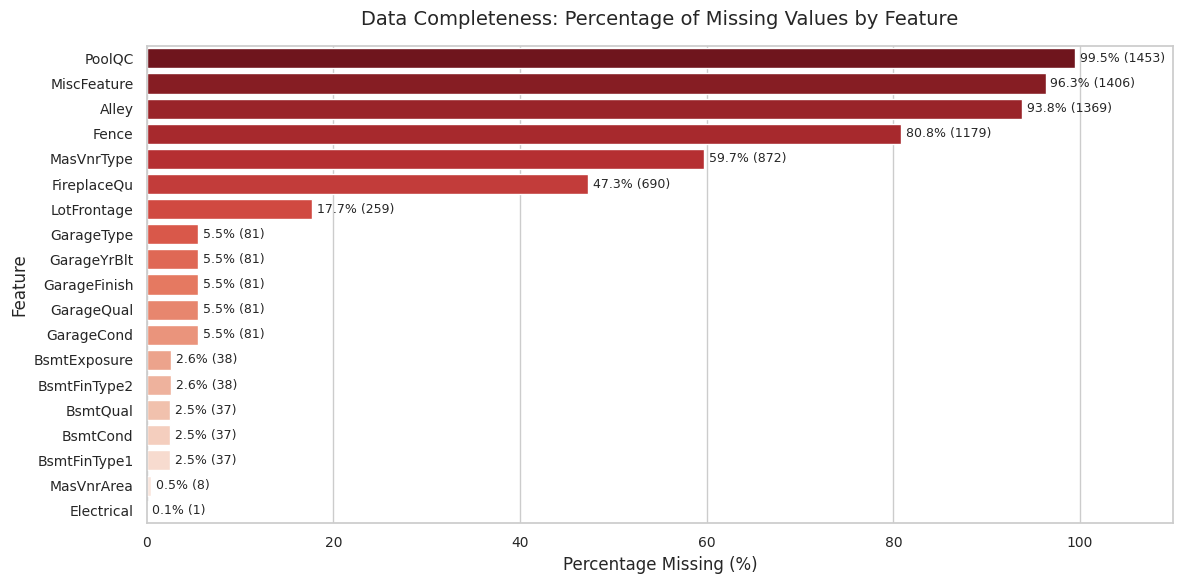

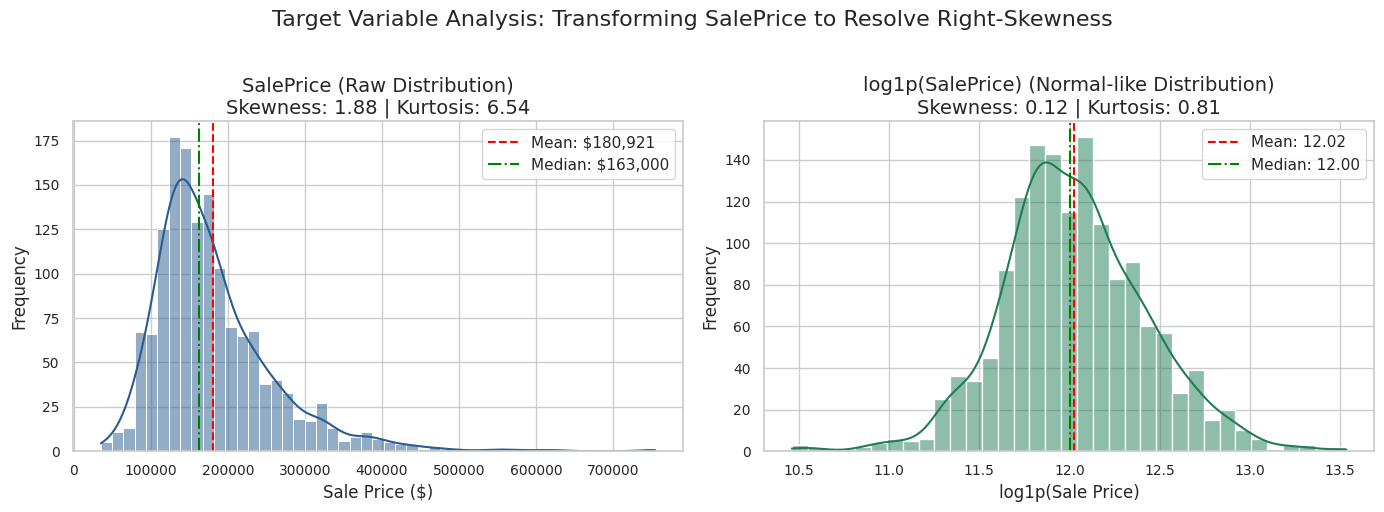

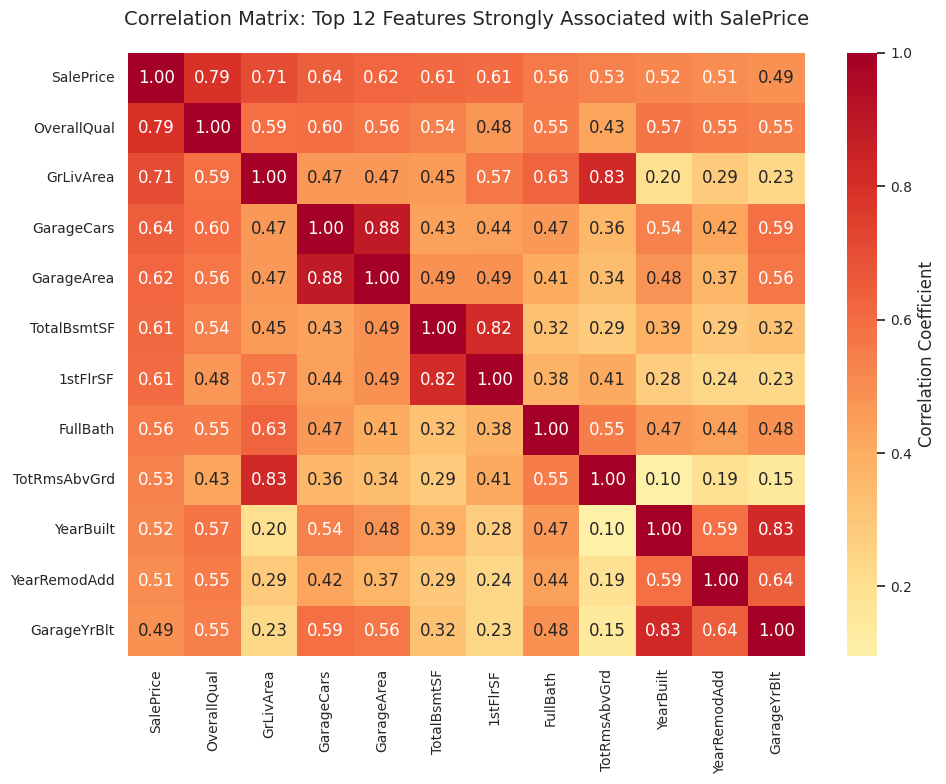

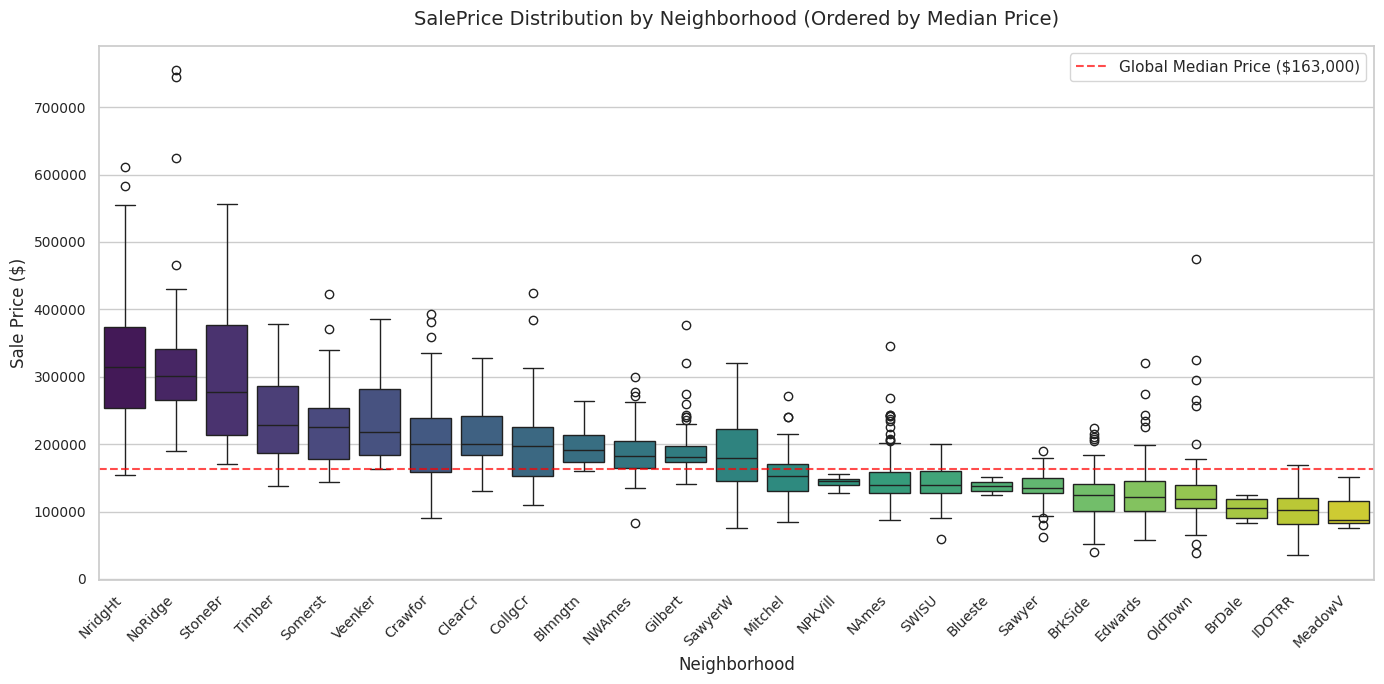

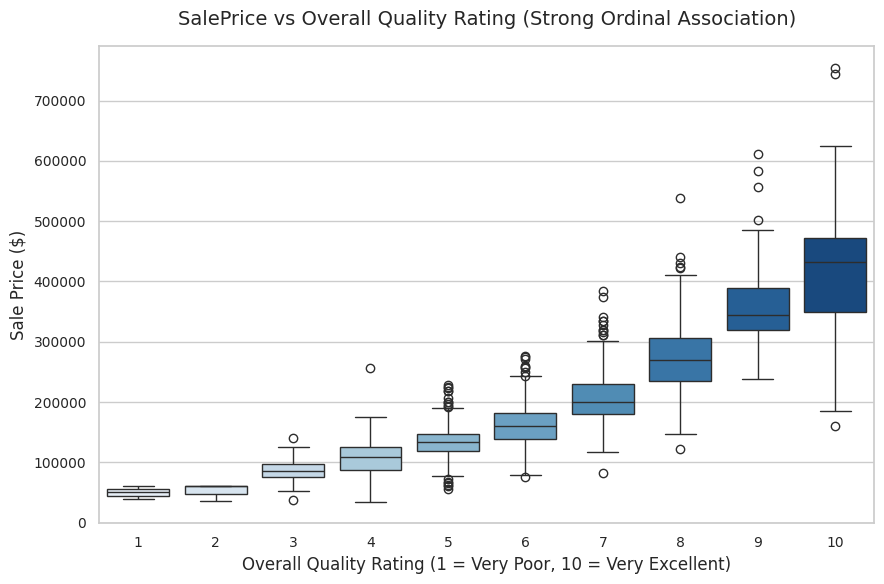

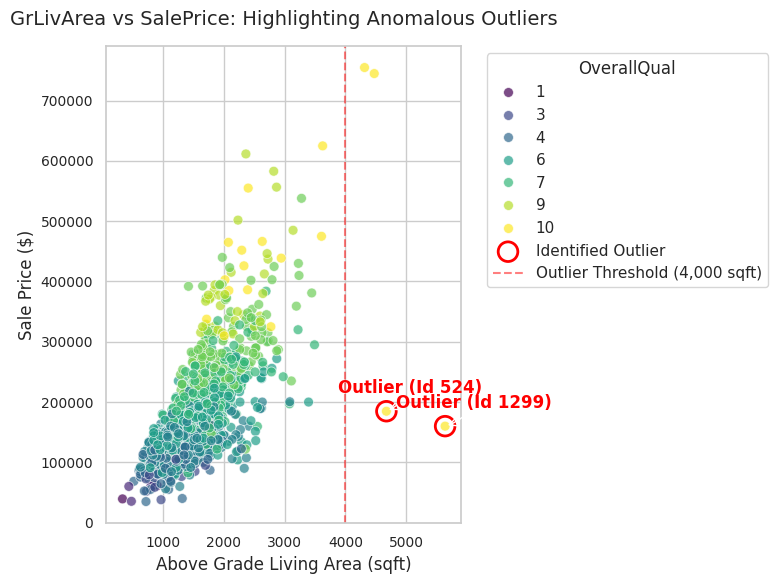

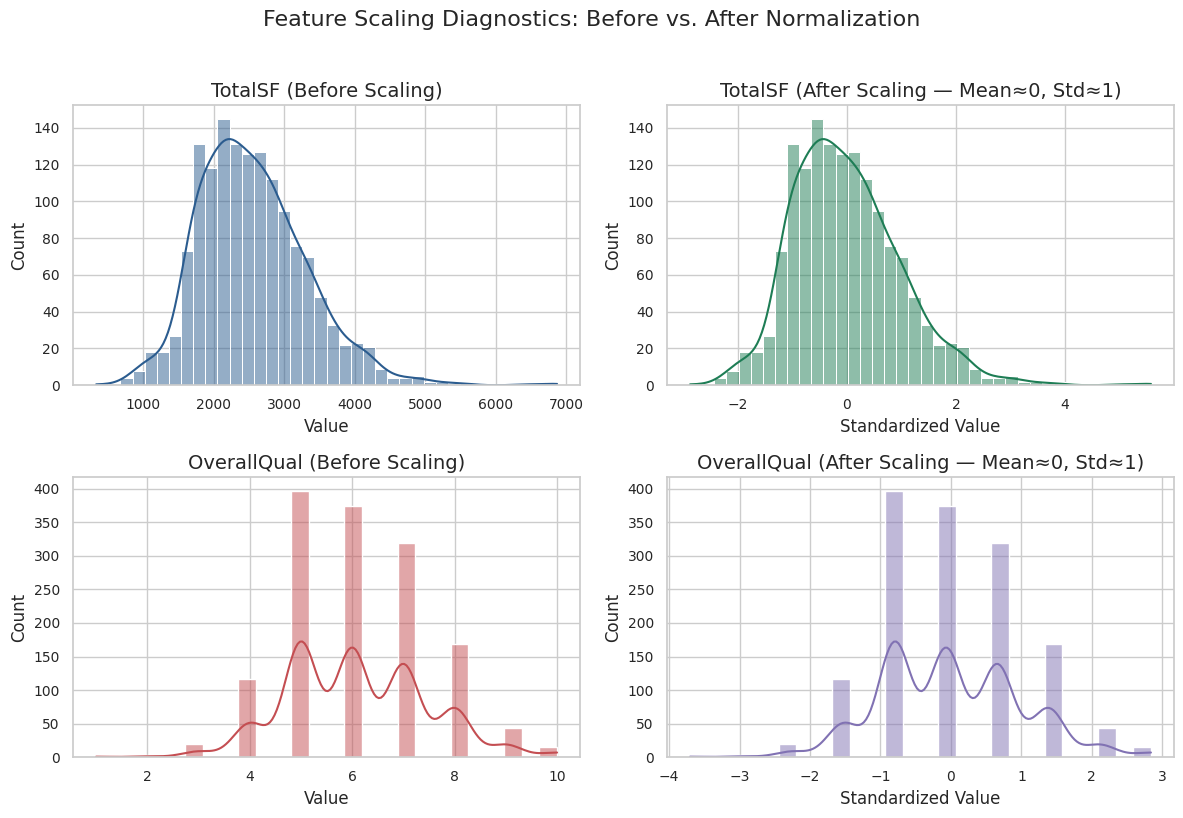

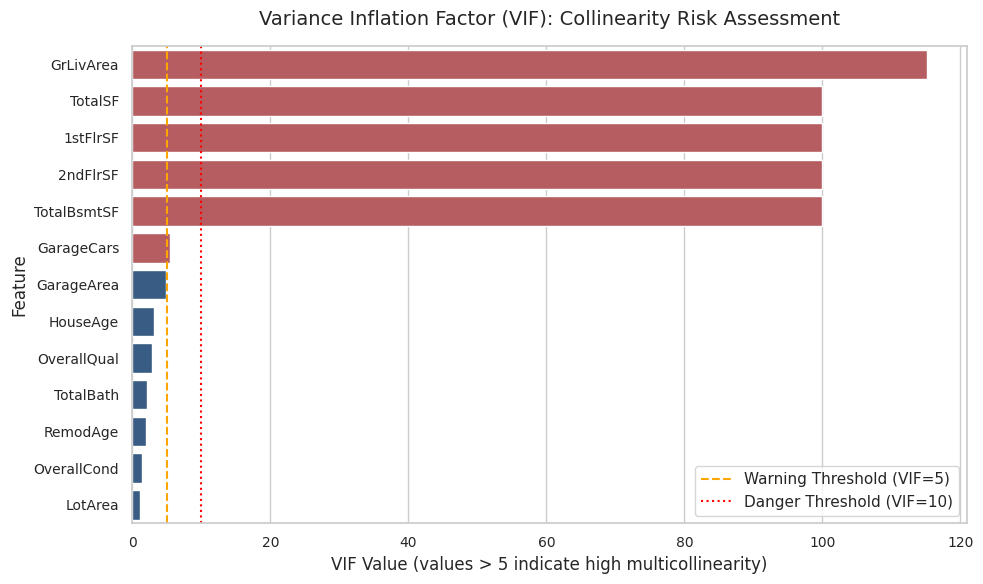

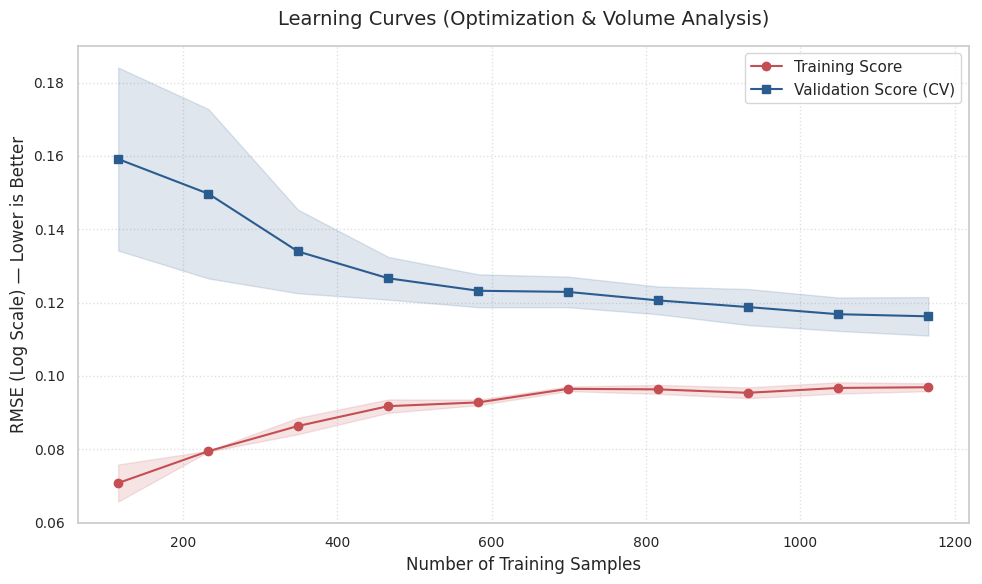

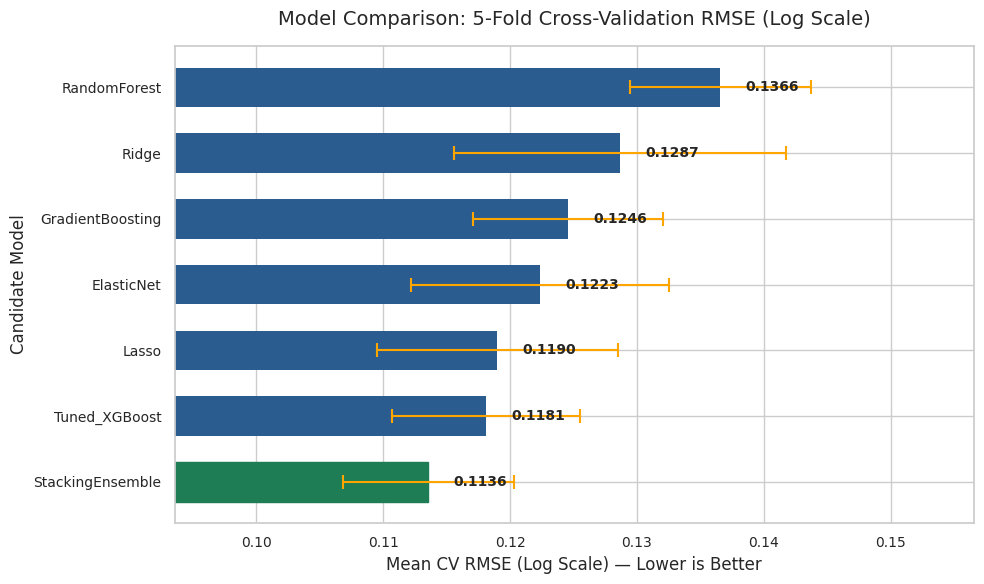

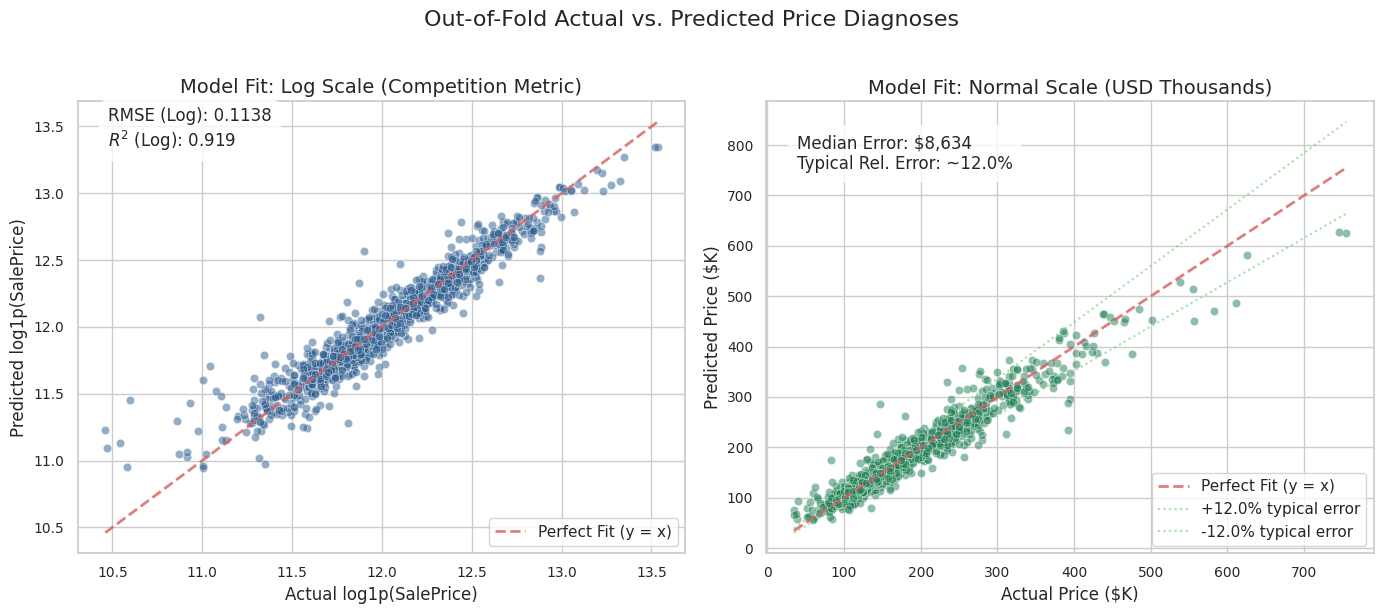

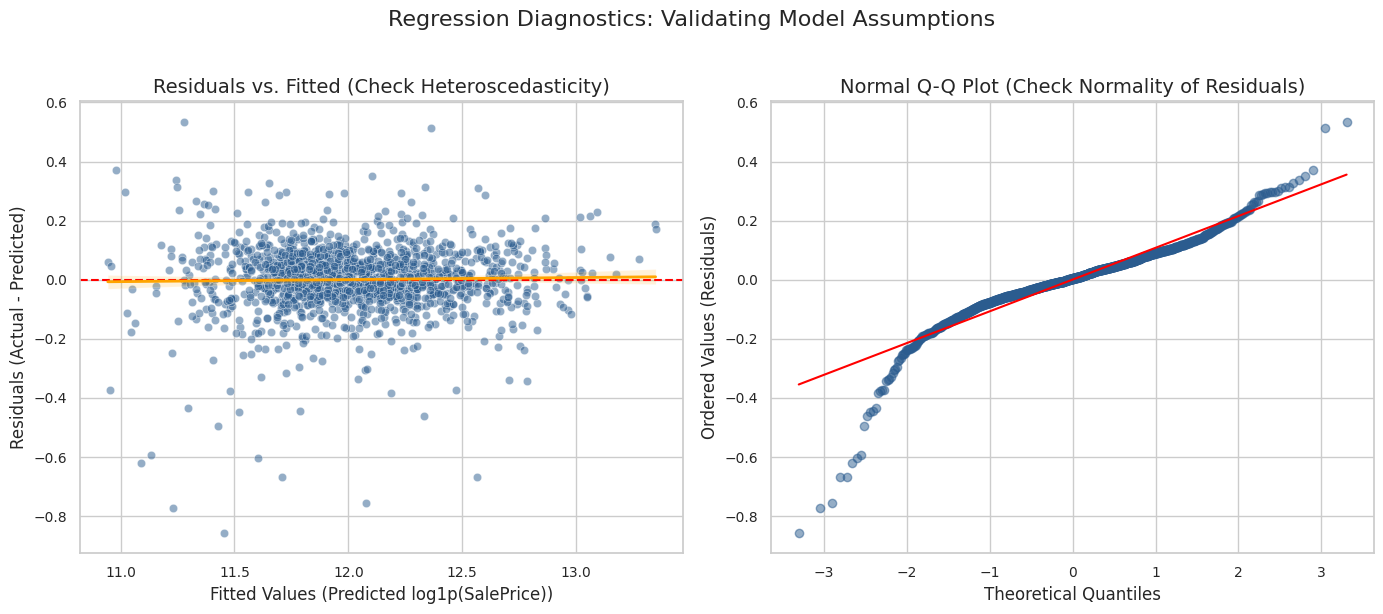

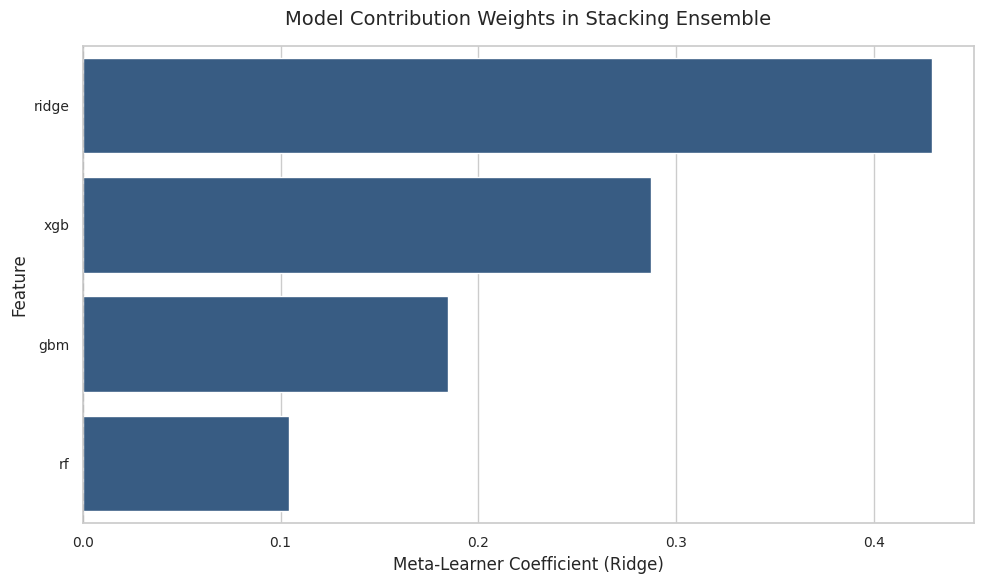

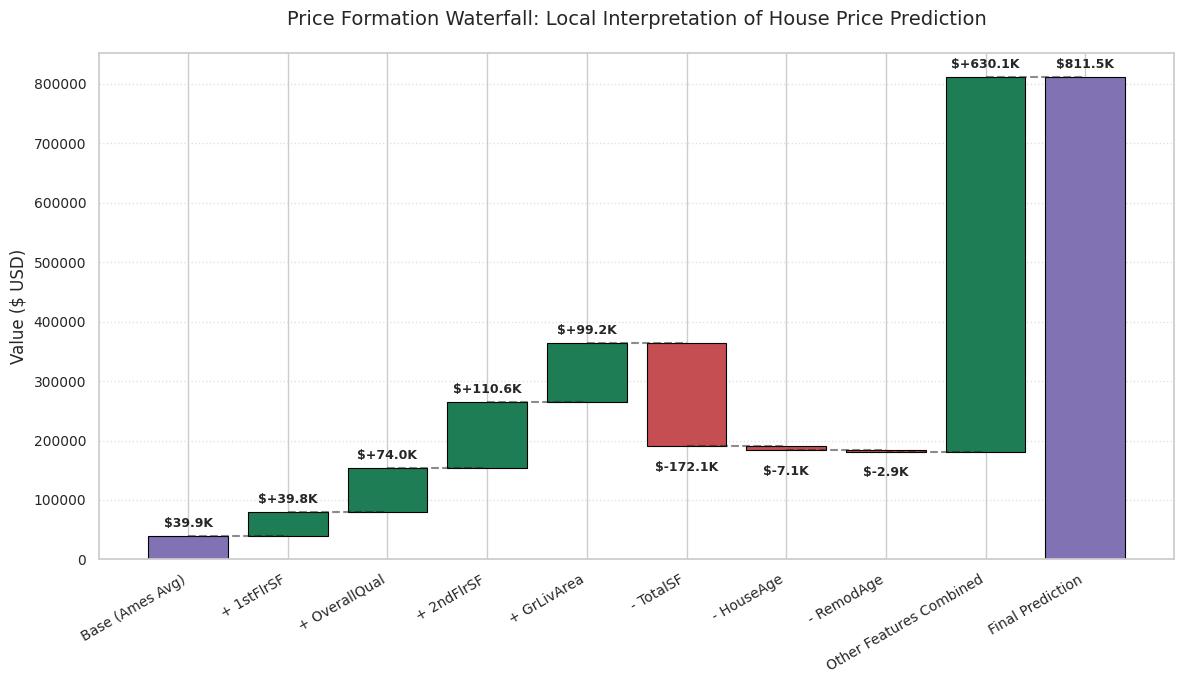

In [123]:
if __name__ == "__main__":
    main()